In [1]:
import pandas as pd

# Load the parquet file we just saved
df = pd.read_parquet("../data/raw/weather_sofia_2024.parquet")

# Basic shape information
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn names and data types:")
print(df.dtypes)
print(f"\nFirst 5 rows:")
df.head()

Rows: 8784
Columns: 5

Column names and data types:
timestamp                  datetime64[us]
shortwave_radiation_wm2           float64
city                                  str
latitude                          float64
longitude                         float64
dtype: object

First 5 rows:


,timestamp,shortwave_radiation_wm2,city,latitude,longitude
0,2024-01-01 00:00:00,0.0,Sofia,42.7065,23.3219
1,2024-01-01 01:00:00,0.0,Sofia,42.7065,23.3219
2,2024-01-01 02:00:00,0.0,Sofia,42.7065,23.3219
3,2024-01-01 03:00:00,0.0,Sofia,42.7065,23.3219
4,2024-01-01 04:00:00,0.0,Sofia,42.7065,23.3219


In [2]:
# Basic statistics for the radiation column
print("Basic statistics:")
print(df["shortwave_radiation_wm2"].describe())

print(f"\nMissing values per column:")
print(df.isnull().sum())

print(f"\nDate range covered:")
print(f"From: {df['timestamp'].min()}")
print(f"To:   {df['timestamp'].max()}")

Basic statistics:
count    8784.000000
mean      182.381944
std       257.566491
min         0.000000
25%         0.000000
50%         8.000000
75%       337.000000
max       958.000000
Name: shortwave_radiation_wm2, dtype: float64

Missing values per column:
timestamp                  0
shortwave_radiation_wm2    0
city                       0
latitude                   0
longitude                  0
dtype: int64

Date range covered:
From: 2024-01-01 00:00:00
To:   2024-12-31 23:00:00


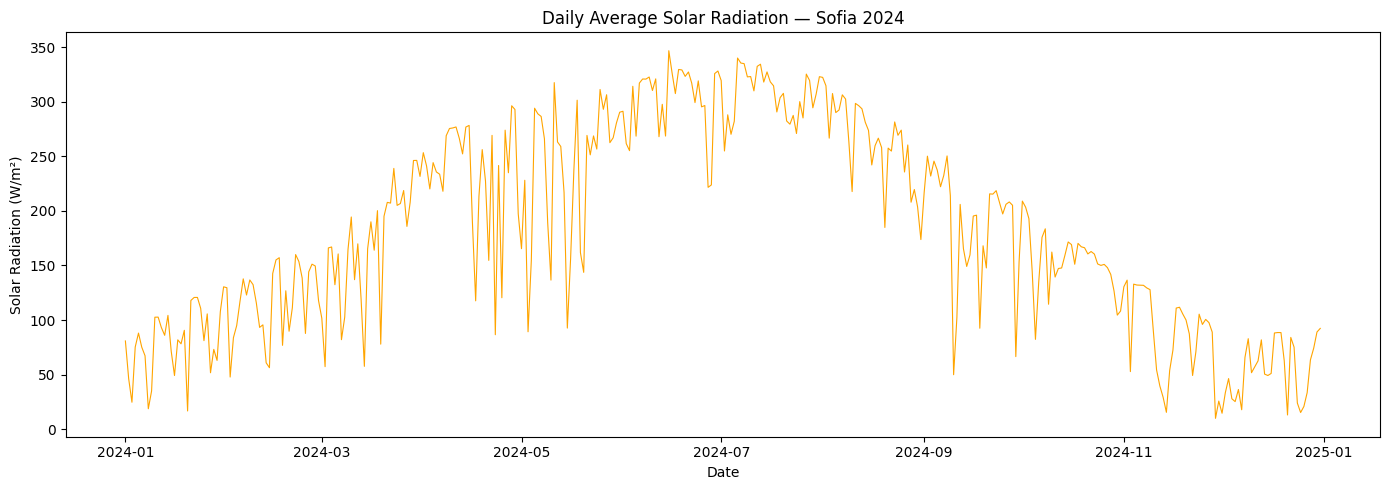

In [3]:
import matplotlib.pyplot as plt

# Calculate daily average radiation (easier to see seasonal pattern than hourly)
df["date"] = df["timestamp"].dt.date  # extract just the date part
daily_avg = df.groupby("date")["shortwave_radiation_wm2"].mean()

# Create the chart
plt.figure(figsize=(14, 5))  # width=14 inches, height=5 inches
plt.plot(daily_avg.index, daily_avg.values, color="orange", linewidth=0.8)
plt.title("Daily Average Solar Radiation — Sofia 2024")
plt.xlabel("Date")
plt.ylabel("Solar Radiation (W/m²)")
plt.tight_layout()
plt.show()